Last edited: 1/28/2026, 3:38 PM CST
# Bias vs. Variance Explained Analysis for Nonstationary GEV Fits to CMIP6 Data

In [2]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe, linregress

from config import DATA_ROOT
from src.utils import compute_ecdf, extract_model_name
from src.cmip_dataclass import CMIP6EnsembleConfig
from src.plotting_presets import get_presets

# import custom stuff
from ambpy.plotutils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [3]:
# Set color and marker sets for CMIP models
# 10 High-Contrast, Colorblind-Friendly Hex Codes (Paul Tol / Okabe-Ito)
colors = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', 
          '#AA3377', '#EE7733', '#009988', '#332288', '#BBBBBB']

# Marker Set
markers = ['o', 's', 'D'] # Circle, Square, Diamond

## Step 0: Set Data Attributes for Analysis

In [48]:
# shared attributes
fit = 'nonstat'
anom_type = "raw"

# set anomaly type
if anom_type == 'raw':
    data_type = 'raw'
else:
    data_type = f"anom_{anom_type}"

In [49]:
# attributes of ERA5 data
TMIN = 1979
era5_variable = 't2m_annual_max'

In [50]:
# attributes of CMIP data
cmip_variable = 'tas_annual_max'
CMIPConfig = CMIP6EnsembleConfig.from_yaml(
    'config/meta.yaml',
    'config/qc.yaml'
)

# make file/model matcher for 
data_path = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev'

# Make all landonly file names
fnames = [f for f in data_path.glob(f"*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

modelname_filepath_matcher = {
extract_model_name(f): f for f in fnames
}

## Step 1: Import ERA5 Data and Initialize Quantities of Interest for CMIP Comparison

In [51]:
# import relevant ERA5 file
ds_era5 = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_{era5_variable}_1deg_landonly_gev_{fit}_TMIN{TMIN}.nc', engine='netcdf4')
PER_DECADE_CONVERSTION_FACTOR = 10 / len(ds_era5.year.values)

# store flattened, screened numpy arrays of ERA5 fit variables for regressions and bias calculations later
if fit == 'nonstat':
    era5_loc, era5_loc_trend = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_scale, era5_scale_trend = ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_shape, era5_shape_trend = ds_era5[f'shape_{data_type}'].values.flatten(), ds_era5[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

elif fit == 'stat':
    era5_loc, era5_scale, era5_shape = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'shape_{data_type}'].values.flatten()

else:
    raise ValueError("Invalid `fit` variable.")


In [52]:
# get number of models for this variable
N_active_models = len(
    list(m for m in CMIPConfig.iter_active_models(cmip_variable))
)

if fit == 'nonstat':
    # median absolute deviation
    med_abs_dev = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

    mean_abs_dev = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

    r2s = {
        'loc': np.zeros(N_active_models),
        'loc_trend': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'scale_trend': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
        'shape_trend': np.zeros(N_active_models)
    }

elif fit == 'stat':
    med_abs_dev = {
        'loc': np.zeros(N_active_models),
        'scale': np.zeros(N_active_models),
        'shape': np.zeros(N_active_models),
    }

else:
    raise ValueError("Invalid `fit`.")

### Test: Scatter Plot of ERA against model

In [7]:
test_model = 'AWI-CM-1-1-MR'
tmp_ds = xr.open_dataset(modelname_filepath_matcher[test_model])

m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

In [8]:
np.nanpercentile(m_loc, [0.1, 0.5, 1, 5, 10, 90, 95, 99, phi, 99.9])

NameError: name 'phi' is not defined

In [32]:
def mutual_mask_perc(x, y, p_lo, p_hi):
    xnew = x[
        (x >= np.nanpercentile(x, p_lo)) & (x <= np.nanpercentile(x, p_hi))
    ]
    ynew = y[
        (x >= np.nanpercentile(x, p_lo)) & (x <= np.nanpercentile(x, p_hi))
    ]

    yfinal = ynew[
        (ynew >= np.nanpercentile(y, p_lo)) & (ynew <= np.nanpercentile(y, p_hi))
    ]

    xfinal = xnew[
        (ynew >= np.nanpercentile(y, p_lo)) & (ynew <= np.nanpercentile(y, p_hi))
    ]

    return xfinal, yfinal

In [ ]:
x = np.random.normal(0, 1, 100)
y = np.random.normal(0, 1, 100)

print(np.percentile(x, 1), np.percentile(x, 99), np.percentile(y, 1), np.percentile(y, 99))
print(min(x), max(x), min(y), max(y))

xn, yn = mutual_mask_perc(x, y, 0, 100)

print(min(xn), max(xn), min(yn), max(yn))

print(len(xn), len(yn))

-2.6805442330636793 2.209934419293884 -2.808821345028216 2.195508862859896
-3.539487159884839 2.2202631590194675 -2.8138795329576123 2.2874031091301466
-3.539487159884839 2.2202631590194675 -2.8138795329576123 2.2874031091301466
100 100


In [ ]:
plo = 5
phi = 95

era5_loc_masked, m_loc_masked = mutual_mask_perc(era5_loc, m_loc, plo, phi)
era5_loc_trend_masked, m_loc_trend_masked = mutual_mask_perc(era5_loc_trend, m_loc_trend, plo, phi)

era5_scale_masked, m_scale_masked = mutual_mask_perc(era5_scale, m_scale, plo, phi)
era5_scale_trend_masked, m_scale_trend_masked = mutual_mask_perc(era5_scale_trend, m_scale_trend, plo, phi)

era5_shape_masked, m_shape_masked = mutual_mask_perc(era5_shape, m_shape, plo, phi)
era5_shape_trend_masked, m_shape_trend_masked = mutual_mask_perc(era5_shape_trend, m_shape_trend, plo, phi)


In [ ]:
regl = linregress(era5_loc_masked, m_loc_masked)
ml, bl, r2l = regl.slope, regl.intercept, regl.rvalue**2

reglt = linregress(era5_loc_trend_masked, m_loc_trend_masked)
mlt, blt, r2lt = reglt.slope, reglt.intercept, reglt.rvalue**2

regsc = linregress(era5_scale_masked, m_scale_masked)
msc, bsc, r2sc = regsc.slope, regsc.intercept, regsc.rvalue**2

regsct = linregress(era5_scale_trend_masked, m_scale_trend_masked)
msct, bsct, r2sct = regsct.slope, regsct.intercept, regsct.rvalue**2

regsh = linregress(era5_shape_masked, m_shape_masked)
msh, bsh, r2sh = regsh.slope, regsh.intercept, regsh.rvalue**2

regsht = linregress(era5_shape_trend_masked, m_shape_trend_masked)
msht, bsht, r2sht = regsht.slope, regsht.intercept, regsht.rvalue**2

slopes = [ml, mlt, msc, msct, msh, msht]
inters = [bl, blt, bsc, bsct, bsh, bsht]
r2s = [r2l, r2lt, r2sc, r2sct, r2sh, r2sht]

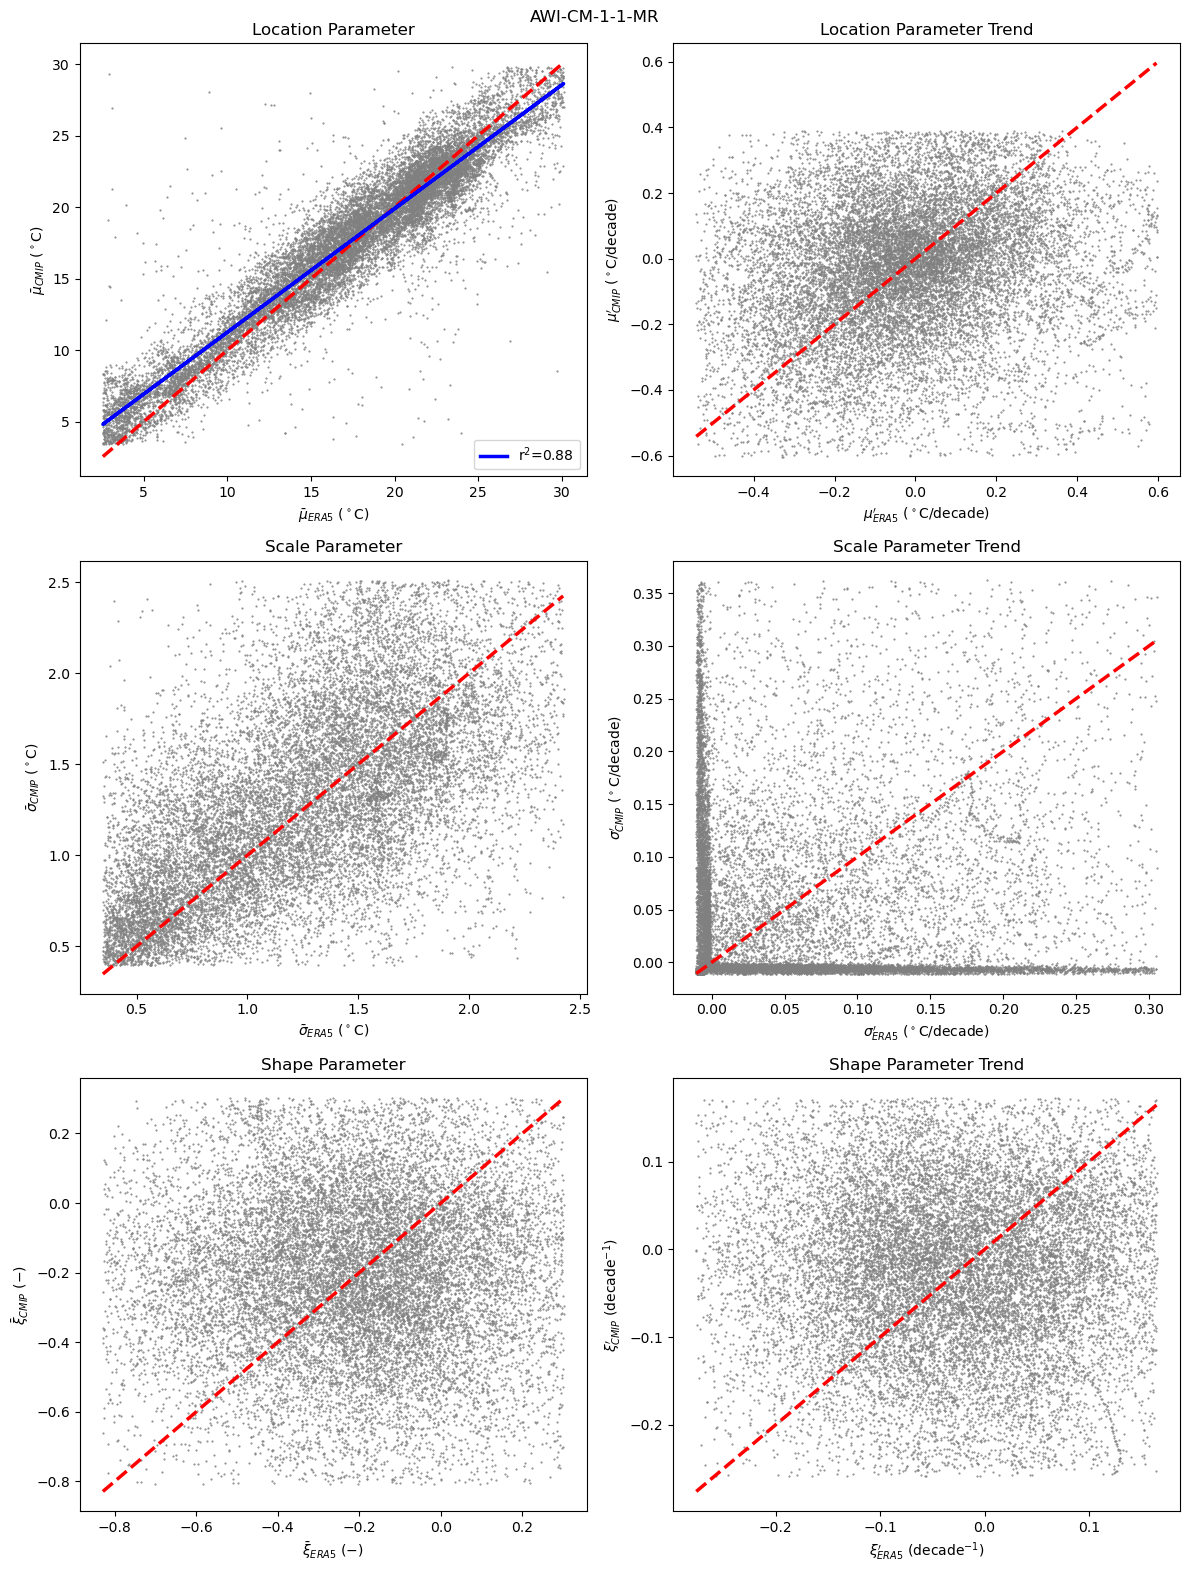

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12, 16))

titles = [r'Location Parameter', r'Location Parameter Trend',
          r'Scale Parameter', r'Scale Parameter Trend',
          r'Shape Parameter', r'Shape Parameter Trend']

x_labels = [r'$\bar{\mu}_{ERA5}$ ($^\circ$C)', r"$\mu_{ERA5}'$ ($^\circ$C/decade)",
              r'$\bar{\sigma}_{ERA5}$ ($^\circ$C)', r"$\sigma_{ERA5}'$ ($^\circ$C/decade)",
              r'$\bar{\xi}_{ERA5}$ ($-$)', r"$\xi_{ERA5}'$ (decade$^{-1}$)"]

y_labels = [r'$\bar{\mu}_{CMIP}$ ($^\circ$C)', r"$\mu_{CMIP}'$ ($^\circ$C/decade)",
              r'$\bar{\sigma}_{CMIP}$ ($^\circ$C)', r"$\sigma_{CMIP}'$ ($^\circ$C/decade)",
              r'$\bar{\xi}_{CMIP}$ ($-$)', r"$\xi_{CMIP}'$ (decade$^{-1}$)"]

x_data = [era5_loc_masked, era5_loc_trend_masked,
          era5_scale_masked, era5_scale_trend_masked,
          era5_shape_masked, era5_shape_trend_masked]

y_data = [m_loc_masked, m_loc_trend_masked,
          m_scale_masked, m_scale_trend_masked,
          m_shape_masked, m_shape_trend_masked]

for (a, x, y, x_label, y_label, title) in zip(ax.flatten(), x_data, y_data, x_labels, y_labels, titles):
    a.scatter(x, y, s=1, marker='.', c='grey')
    a.plot(np.arange(min(x), max(x), (max(x) - min(x))/1000),
           np.arange(min(x), max(x), (max(x) - min(x))/1000),
           linewidth=2.5, linestyle='dashed', color='r')
    a.set_title(title)
    a.set_xlabel(x_label)
    a.set_ylabel(y_label)

ax[0, 0].plot(era5_loc_masked, m * era5_loc_masked + b, linestyle='solid', color='b', linewidth=2.5, label=f"r$^2$={r2:.2f}")
ax[0, 0].legend()
fig.suptitle(test_model)

fig.tight_layout()
plt.show()


In [33]:
def plot_scatter_regression(x_data, y_data, slopes, intercepts, r2s, model_name):
    fig, ax = plt.subplots(3, 2, figsize=(12, 16))
    titles = [r'Location Parameter', r'Location Parameter Trend',
            r'Scale Parameter', r'Scale Parameter Trend',
            r'Shape Parameter', r'Shape Parameter Trend']

    x_labels = [r'$\bar{\mu}_{ERA5}$ ($^\circ$C)', r"$\mu_{ERA5}'$ ($^\circ$C/decade)",
                r'$\bar{\sigma}_{ERA5}$ ($^\circ$C)', r"$\sigma_{ERA5}'$ ($^\circ$C/decade)",
                r'$\bar{\xi}_{ERA5}$ ($-$)', r"$\xi_{ERA5}'$ (decade$^{-1}$)"]

    y_labels = [r'$\bar{\mu}_{CMIP}$ ($^\circ$C)', r"$\mu_{CMIP}'$ ($^\circ$C/decade)",
                r'$\bar{\sigma}_{CMIP}$ ($^\circ$C)', r"$\sigma_{CMIP}'$ ($^\circ$C/decade)",
                r'$\bar{\xi}_{CMIP}$ ($-$)', r"$\xi_{CMIP}'$ (decade$^{-1}$)"]
    
    for (a, x, y, slope, intercept, r2, x_label, y_label, title) in zip(ax.flatten(), x_data, y_data, slopes, intercepts, r2s, x_labels, y_labels, titles):
        # data and regression lines
        a.scatter(x, y, s=1, marker='.', c='grey')  # data
        a.plot(np.arange(min(x), max(x), (max(x) - min(x))/1000),
                np.arange(min(x), max(x), (max(x) - min(x))/1000),
                linewidth=2.5, linestyle='dashed', color='r')  # one to one line
        a.plot(x, slope * x + intercept, linestyle='solid', color='b', linewidth=2.5, label=f"r$^2$={r2:.2f}")  # regression line

        # aesthetics
        a.set_title(title)
        a.set_xlabel(x_label)
        a.set_ylabel(y_label)
        a.legend()
    
    fig.suptitle(f"Model: {model_name}")
    fig.tight_layout()

    fname = make_figure_filename(f'era5_{model_name}_nonstat_gev_comparison_{cmip_variable}_{anom_type}', 'png', 'figs/checks')
    fig.savefig(fname, dpi=300)
    print(f"     Figure saved to: {fname}")

Figure saved to: figs/checks/2026-02-03-era5_AWI-CM-1-1-MR_nonstat_gev_comparison.png


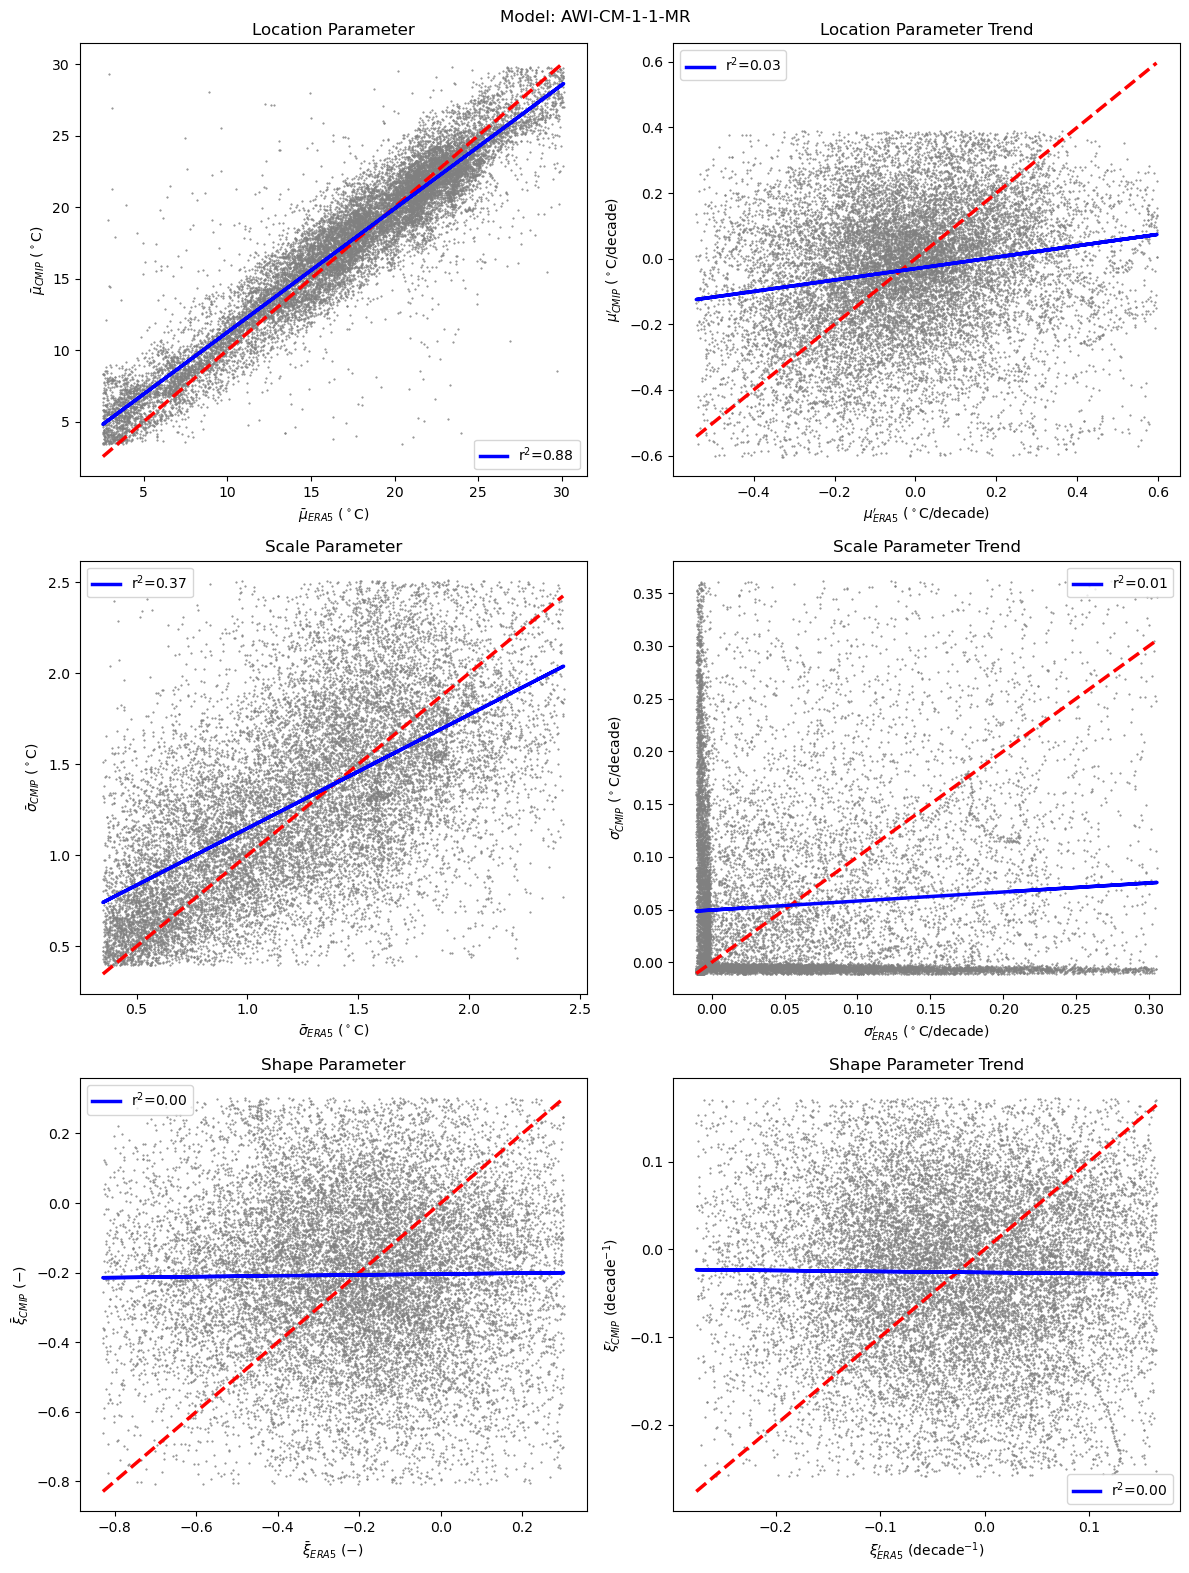

In [ ]:
plot_scatter_regression(x_data, y_data, slopes, inters, r2s, test_model)
plt.show()

## Step 2: Loop Through CMIP Models and Carry Out Analysis

In [53]:
# percentiles for masking
plo = 5
phi = 95

# loop through models 
for (i, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
    print(f"\n⚒️ Working on {m.name}...")
    tmp_ds = xr.open_dataset(
        modelname_filepath_matcher[m.name]
    )

    # carry out calculations for both nonstationary and stationary cases
    if fit == 'nonstat':
        # extract model variables
        m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

        # mutually mask era5 and model parameters
        era5_loc_masked, m_loc_masked = mutual_mask_perc(era5_loc, m_loc, plo, phi)
        era5_loc_trend_masked, m_loc_trend_masked = mutual_mask_perc(era5_loc_trend, m_loc_trend, plo, phi)

        era5_scale_masked, m_scale_masked = mutual_mask_perc(era5_scale, m_scale, plo, phi)
        era5_scale_trend_masked, m_scale_trend_masked = mutual_mask_perc(era5_scale_trend, m_scale_trend, plo, phi)

        era5_shape_masked, m_shape_masked = mutual_mask_perc(era5_shape, m_shape, plo, phi)
        era5_shape_trend_masked, m_shape_trend_masked = mutual_mask_perc(era5_shape_trend, m_shape_trend, plo, phi)

        # compute absolute deviations of parameters between model and era
        tmp_abs_dev_loc = m_loc_masked - era5_loc_masked
        tmp_abs_dev_loc_trend = m_loc_trend_masked - era5_loc_trend_masked

        tmp_abs_dev_scale = m_scale_masked - era5_scale_masked
        tmp_abs_dev_scale_trend = m_scale_trend_masked - era5_scale_trend_masked

        tmp_abs_dev_shape = m_shape_masked - era5_shape_masked
        tmp_abs_dev_shape_trend = m_shape_trend_masked - era5_shape_trend_masked

        # store nanmedians and nanmeans
        ## nanmedian
        med_abs_dev['loc'][i] = np.nanmedian(tmp_abs_dev_loc)
        med_abs_dev['loc_trend'][i] = np.nanmedian(tmp_abs_dev_loc_trend)

        med_abs_dev['scale'][i] = np.nanmedian(tmp_abs_dev_scale)
        med_abs_dev['scale_trend'][i] = np.nanmedian(tmp_abs_dev_scale_trend)

        med_abs_dev['shape'][i] = np.nanmedian(tmp_abs_dev_shape)
        med_abs_dev['shape_trend'][i] = np.nanmedian(tmp_abs_dev_shape_trend)

        ## nanmean
        mean_abs_dev['loc'][i] = np.nanmean(tmp_abs_dev_loc)
        mean_abs_dev['loc_trend'][i] = np.nanmean(tmp_abs_dev_loc_trend)

        mean_abs_dev['scale'][i] = np.nanmean(tmp_abs_dev_scale)
        mean_abs_dev['scale_trend'][i] = np.nanmean(tmp_abs_dev_scale_trend)

        mean_abs_dev['shape'][i] = np.nanmean(tmp_abs_dev_shape)
        mean_abs_dev['shape_trend'][i] = np.nanmean(tmp_abs_dev_shape_trend)

        # regress against ERA5 equivalents
        # NOTE: nan_policy='omit' because nans are ocean values
        loc_reg = linregress(era5_loc_masked, m_loc_masked)
        loc_slope, loc_inter, loc_r2 = loc_reg.slope, loc_reg.intercept, loc_reg.rvalue**2
        r2s['loc'][i] = loc_r2

        loc_trend_reg = linregress(era5_loc_trend_masked, m_loc_trend_masked)
        loct_slope, loct_inter, loct_r2 = loc_trend_reg.slope, loc_trend_reg.intercept, loc_trend_reg.rvalue**2
        r2s['loc_trend'][i] = loct_r2

        scale_reg = linregress(era5_scale_masked, m_scale_masked)
        scale_slope, scale_inter, scale_r2 = scale_reg.slope, scale_reg.intercept, scale_reg.rvalue**2
        r2s['scale'][i] = scale_r2

        scale_trend_reg = linregress(era5_scale_trend_masked, m_scale_trend_masked)
        scalet_slope, scalet_inter, scalet_r2 = scale_trend_reg.slope, scale_trend_reg.intercept, scale_trend_reg.rvalue**2
        r2s['scale_trend'][i] = scalet_r2

        shape_reg = linregress(era5_shape_masked, m_shape_masked)
        shape_slope, shape_inter, shape_r2 = shape_reg.slope, shape_reg.intercept, shape_reg.rvalue**2
        r2s['shape'][i] = shape_r2

        shape_trend_reg = linregress(era5_shape_trend_masked, m_shape_trend_masked)
        shapet_slope, shapet_inter, shapet_r2 = shape_trend_reg.slope, shape_trend_reg.intercept, shape_trend_reg.rvalue**2
        r2s['shape_trend'][i] = shapet_r2

        # make check plot
        plot_scatter_regression(
            x_data=[era5_loc_masked, era5_loc_trend_masked, era5_scale_masked, era5_scale_trend_masked, era5_shape_masked, era5_shape_trend_masked],
            y_data=[m_loc_masked, m_loc_trend_masked, m_scale_masked, m_scale_trend_masked, m_shape_masked, m_shape_trend_masked],
            slopes=[loc_slope, loct_slope, scale_slope, scalet_slope, shape_slope, shapet_slope],
            intercepts=[loc_inter, loct_inter, scale_inter, scalet_inter, shape_inter, shapet_inter],
            r2s=[loc_r2, loct_r2, scale_r2, scalet_r2, shape_r2, shapet_r2],
            model_name=m.name
        )

        plt.close()

    else:
        import warnings
        warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

    tmp_ds.close()



⚒️ Working on AWI-CM-1-1-MR...
     Figure saved to: figs/checks/2026-02-20-era5_AWI-CM-1-1-MR_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on BCC-CSM2-MR...
     Figure saved to: figs/checks/2026-02-20-era5_BCC-CSM2-MR_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CAMS-CSM1-0...
     Figure saved to: figs/checks/2026-02-20-era5_CAMS-CSM1-0_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CESM2-WACCM...
     Figure saved to: figs/checks/2026-02-20-era5_CESM2-WACCM_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CMCC-CM2-SR5...
     Figure saved to: figs/checks/2026-02-20-era5_CMCC-CM2-SR5_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CMCC-ESM2...
     Figure saved to: figs/checks/2026-02-20-era5_CMCC-ESM2_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CNRM-CM6-1-HR...
     Figure saved to: figs/checks/2026-02-20-era5_CNRM-CM6-1-HR_nonstat_gev_comparison_tas_annual_max_raw.png

⚒️ Working on CNRM-ESM2-1..

✍️ Figure saved to: figs/analysis/2026-02-20-cmip_era5_r2_avgbias_tas_annual_max_raw.png


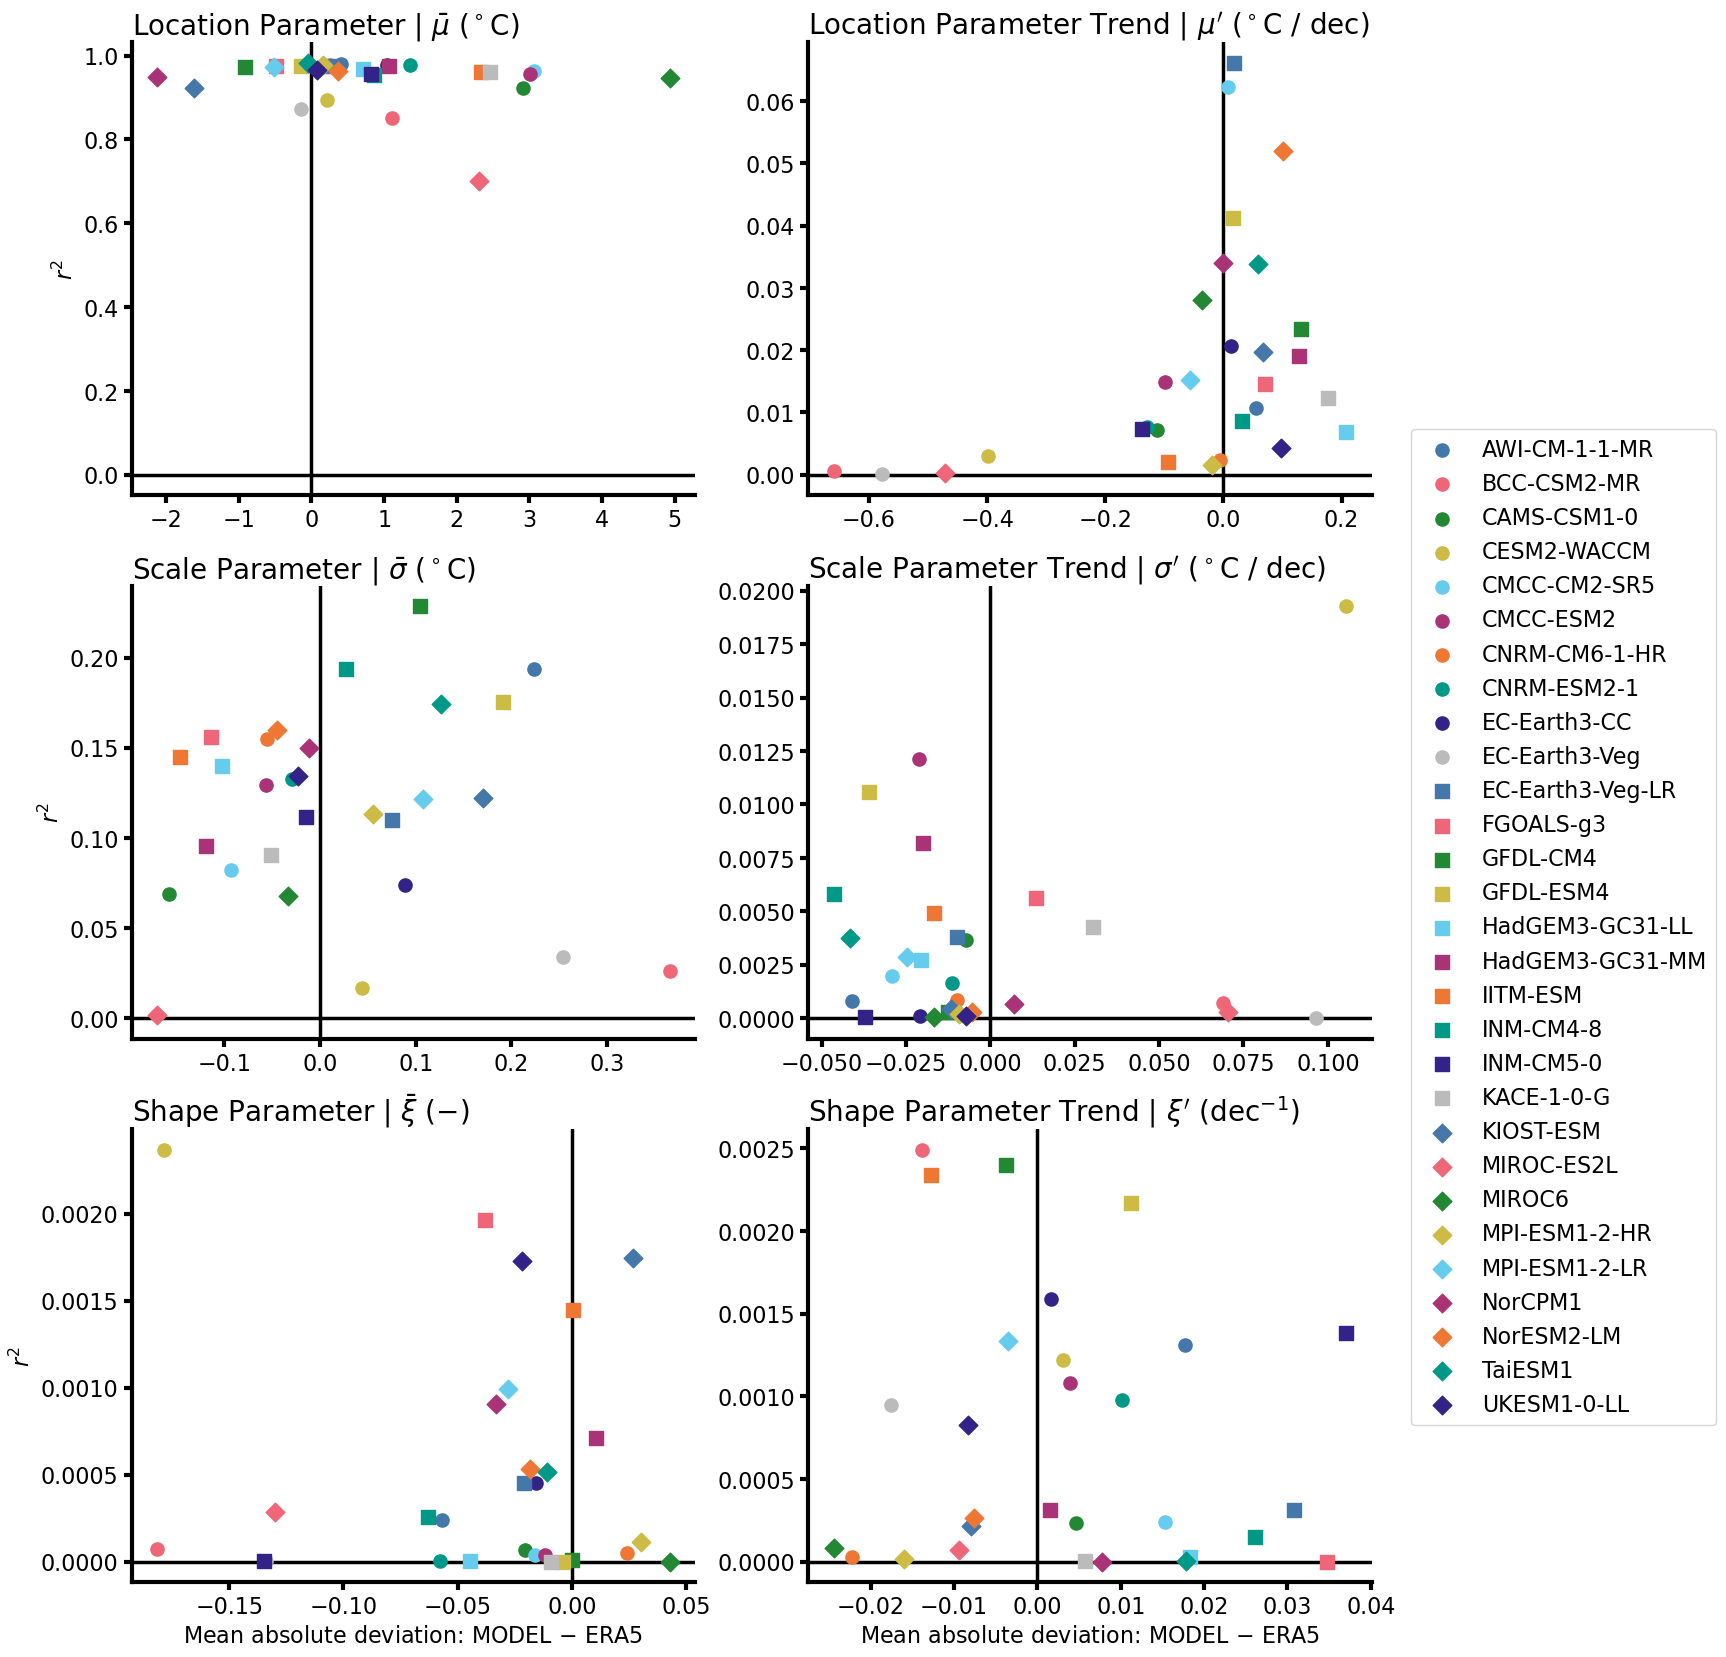

In [54]:
fig, ax = plt.subplots(3, 2, figsize=(16, 20))
titles = [r'Location Parameter | $\bar{\mu}$ $(^\circ$C$)$', r"Location Parameter Trend | $\mu'$ $(^\circ$C / dec$)$",
        r'Scale Parameter | $\bar{\sigma}$ $(^\circ$C$)$', r"Scale Parameter Trend | $\sigma'$ $(^\circ$C / dec$)$",
        r'Shape Parameter | $\bar{\xi}$ $(-)$', r"Shape Parameter Trend | $\xi'$ $($dec$^{-1})$"]
models = list(CMIPConfig.iter_active_models(cmip_variable))

have_ylabels = [0, 2, 4]
have_xlabels = [4, 5]

for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in enumerate(models):
        marker = markers[mdx // 10]  # choose marker
        color = colors[mdx % 10]  # choose color

        a.scatter(mean_abs_dev[var][mdx], r2s[var][mdx], s=90, marker=marker, color=color, label=m.name, zorder=100)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("$r^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Mean absolute deviation: MODEL $-$ ERA5")

ax[1,1].legend(bbox_to_anchor=(1.05, 1.37), frameon=True)
save_figs = True
if save_figs:
    fname = make_figure_filename(f'cmip_era5_r2_avgbias_{cmip_variable}_{anom_type}', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

✍️ Figure saved to: figs/analysis/2026-02-20-cmip_era5_r2_medbias_tas_annual_max_raw.png


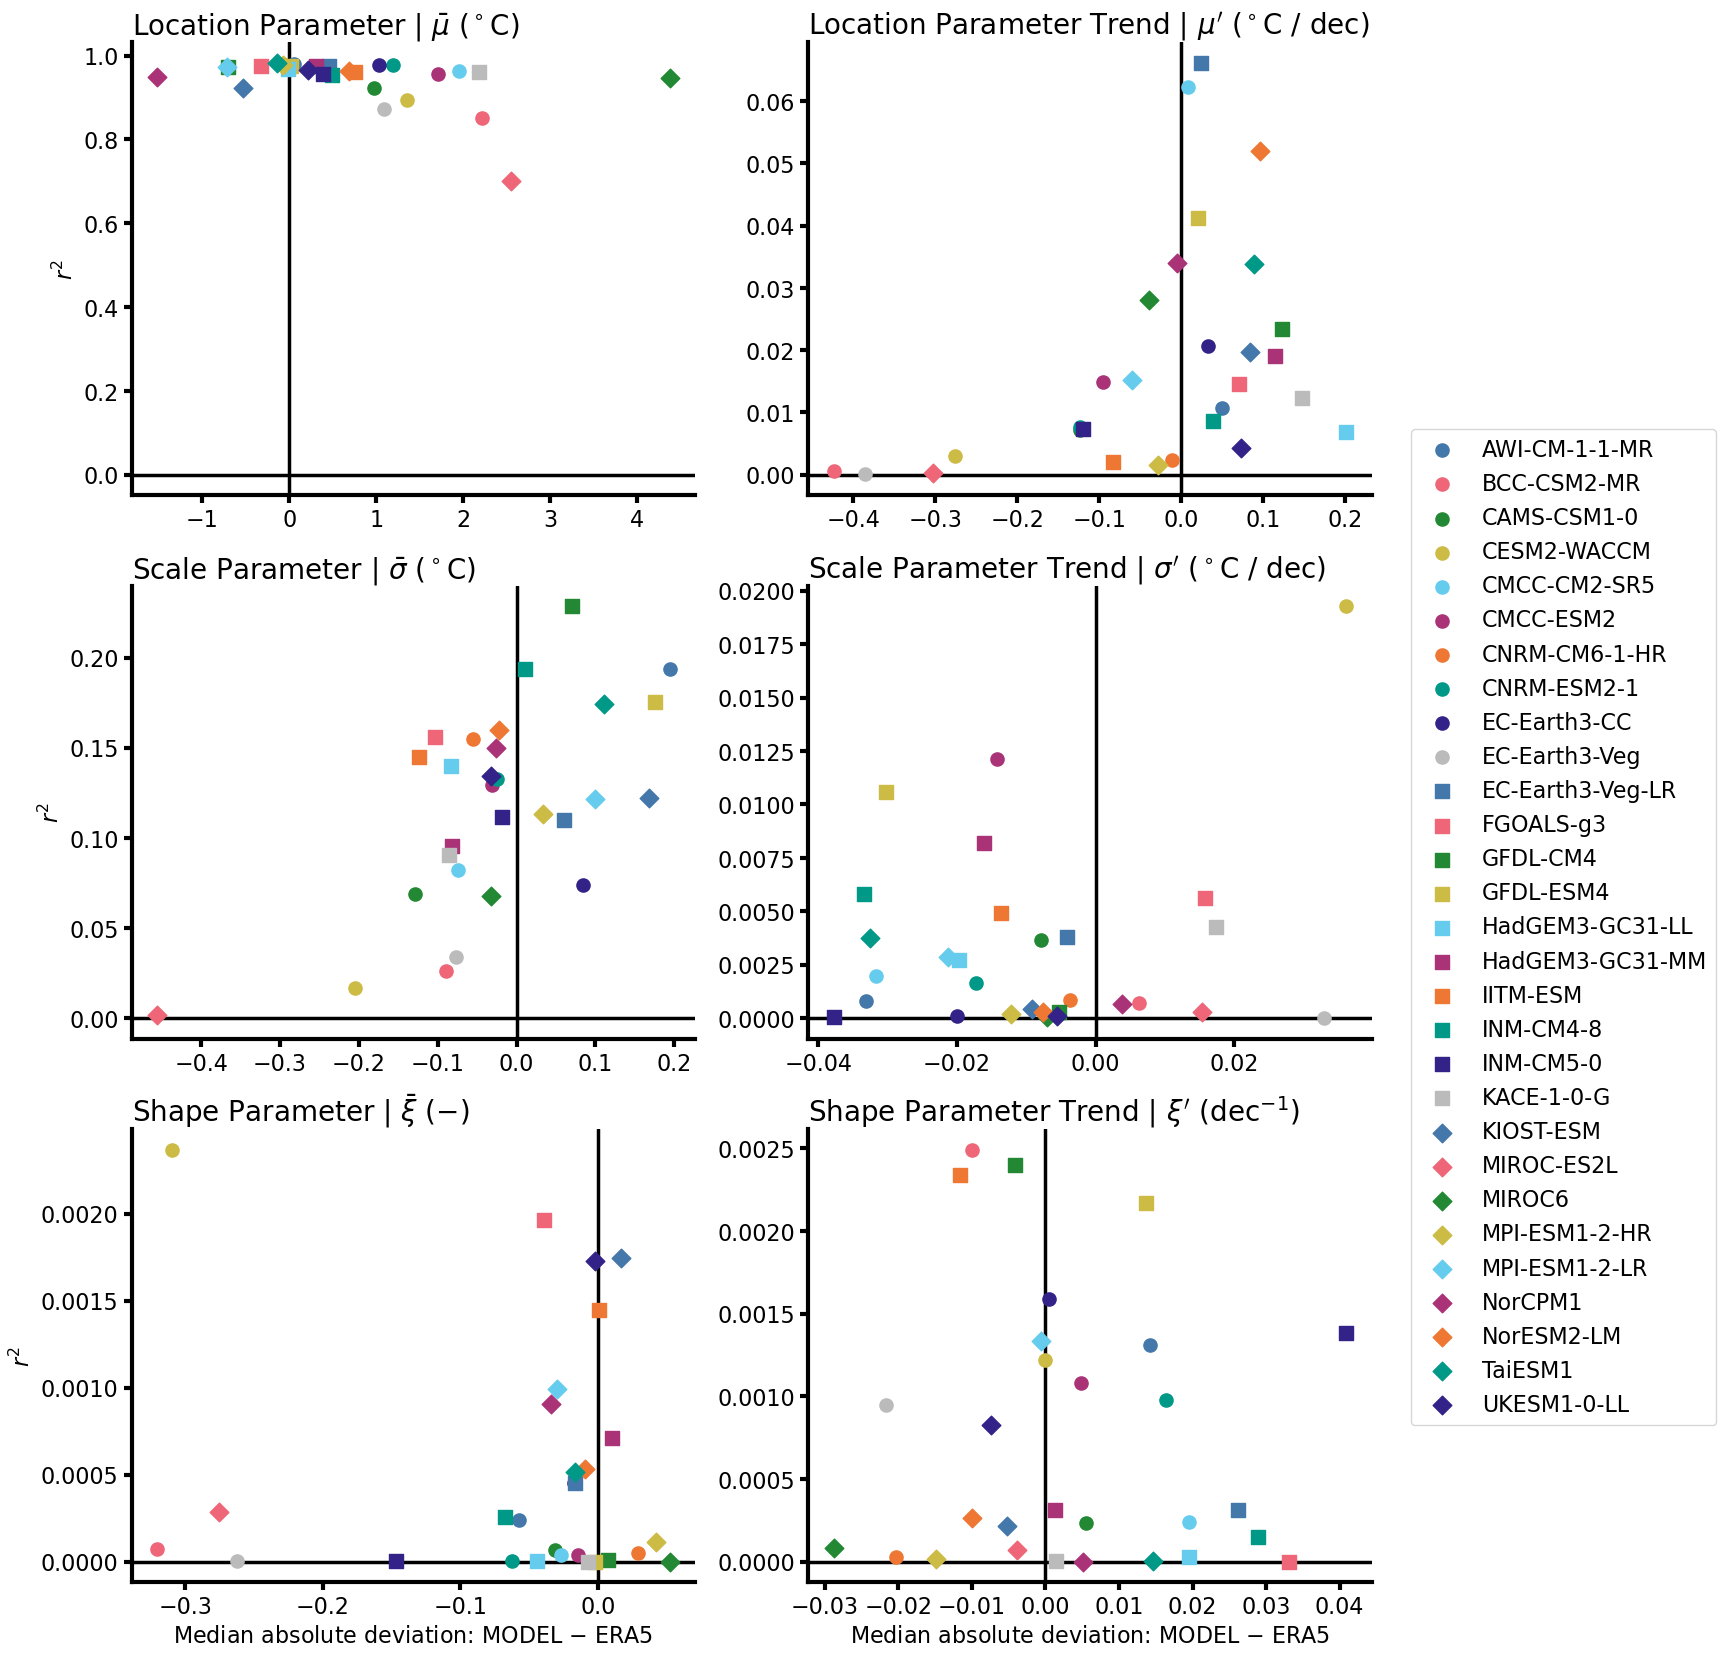

In [55]:
fig, ax = plt.subplots(3, 2, figsize=(16, 20))
titles = [r'Location Parameter | $\bar{\mu}$ $(^\circ$C$)$', r"Location Parameter Trend | $\mu'$ $(^\circ$C / dec$)$",
        r'Scale Parameter | $\bar{\sigma}$ $(^\circ$C$)$', r"Scale Parameter Trend | $\sigma'$ $(^\circ$C / dec$)$",
        r'Shape Parameter | $\bar{\xi}$ $(-)$', r"Shape Parameter Trend | $\xi'$ $($dec$^{-1})$"]
models = list(CMIPConfig.iter_active_models(cmip_variable))

have_ylabels = [0, 2, 4]
have_xlabels = [4, 5]

for (idx, (a, var, title)) in enumerate(zip(ax.flatten(), r2s.keys(), titles)):
    a.axvline(0, 0, 1, linestyle='solid', color='k')
    a.axhline(0, -1, 1, linestyle='solid', color='k')
    for mdx, m in enumerate(models):
        marker = markers[mdx // 10]  # choose marker
        color = colors[mdx % 10]  # choose color

        a.scatter(med_abs_dev[var][mdx], r2s[var][mdx], s=90, marker=marker, color=color, label=m.name, zorder=100)
        a.set_title(title)
        if idx in have_ylabels:
            a.set_ylabel("$r^2$")
        
        if idx in have_xlabels:
            a.set_xlabel("Median absolute deviation: MODEL $-$ ERA5")

ax[1,1].legend(bbox_to_anchor=(1.05, 1.37), frameon=True)

if save_figs:
    fname = make_figure_filename(f'cmip_era5_r2_medbias_{cmip_variable}_{anom_type}', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

In [15]:
# save r2s to a csv file
model_names = list(m.name for m in list(CMIPConfig.iter_active_models(cmip_variable)))

df = pd.DataFrame.from_dict(r2s, orient='index', columns=model_names)

r2_fpath = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev' / f'r2s_{cmip_variable}_{anom_type}.csv'
df.to_csv(r2_fpath)

In [16]:
df

,AWI-CM-1-1-MR,BCC-CSM2-MR,CAMS-CSM1-0,CESM2-WACCM,CMCC-CM2-SR5,CMCC-ESM2,CNRM-CM6-1-HR,CNRM-ESM2-1,EC-Earth3-CC,EC-Earth3-Veg,...,KACE-1-0-G,KIOST-ESM,MIROC-ES2L,MIROC6,MPI-ESM1-2-HR,MPI-ESM1-2-LR,NorCPM1,NorESM2-LM,TaiESM1,UKESM1-0-LL
loc,0.980282,0.850264,0.922350,0.894145,0.962660,0.957065,0.976642,0.976751,0.978671,0.872207,...,9.599483e-01,0.923451,0.701362,9.472049e-01,0.978165,0.972857,9.494881e-01,0.963783,0.982761,0.965627
loc_trend,0.010709,0.000626,0.007178,0.002950,0.062291,0.014840,0.002367,0.007594,0.020609,0.000029,...,1.238216e-02,0.019635,0.000272,2.810728e-02,0.001520,0.015150,3.407505e-02,0.051971,0.033758,0.004272
scale,0.193579,0.026314,0.068783,0.016937,0.081948,0.129056,0.154978,0.132769,0.074068,0.034109,...,9.072707e-02,0.121875,0.001666,6.781587e-02,0.113106,0.121438,1.500396e-01,0.159812,0.174346,0.134109
scale_trend,0.000822,0.000693,0.003638,0.019268,0.001968,0.012114,0.000829,0.001647,0.000096,0.000029,...,4.262707e-03,0.000407,0.000291,5.767338e-05,0.000213,0.002845,6.563137e-04,0.000300,0.003756,0.000077
shape,0.000240,0.000071,0.000067,0.002367,0.000040,0.000038,0.000048,0.000002,0.000450,0.000003,...,5.976123e-07,0.001747,0.000287,4.620117e-07,0.000115,0.000990,9.074755e-04,0.000534,0.000518,0.001729
shape_trend,0.001313,0.002490,0.000231,0.001221,0.000238,0.001077,0.000028,0.000978,0.001588,0.000949,...,4.085884e-06,0.000217,0.000072,8.153546e-05,0.000016,0.001332,3.197036e-07,0.000262,0.000007,0.000826
